In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich.jupyter import display

In [2]:
mps_df = pd.read_csv('./cache/mps_term10.csv')
sittings_df = pd.read_csv('./cache/sittings_term10.csv')
voting_df = pd.read_csv('./cache/voting_term10.csv')

In [3]:
mps_df.columns

Index(['id', 'firstName', 'lastName', 'birthDate', 'birthLocation',
       'educationLevel', 'profession', 'club', 'districtNum', 'districtName',
       'voivodeship', 'numberOfVotes', 'active', 'inactiveCause', 'waiverDesc',
       'percentOfVoting'],
      dtype='object')

# Liczba głosów

## Top 10 posłów pod względem otrzymanych głosów

In [4]:
mps_df[['firstName', 'lastName', 'club', 'numberOfVotes']].sort_values(by='numberOfVotes', ascending=False).head(10)

,firstName,lastName,club,numberOfVotes
399,Donald,Tusk,KO,538634
147,Jarosław,Kaczyński,PiS,177228
370,Adam,Szłapka,KO,149064
262,Barbara,Nowacka,KO,139524
99,Piotr,Gliński,PiS,135339
19,Mariusz,Błaszczak,PiS,127578
410,Małgorzata,Wassermann,PiS,125786
55,Przemysław,Czarnek,PiS,121686
245,Mateusz,Morawiecki,PiS,117064
226,Marlena,Maląg,PiS,109870


## Posłowie z największą ilością głosów per klub

In [5]:
max_numberOfVotes_in_club_series = mps_df.groupby('club')['numberOfVotes'].transform('max')
mps_with_max_numberOfVotes_in_club_series = mps_df[mps_df['numberOfVotes'] == max_numberOfVotes_in_club_series]
result_df = mps_with_max_numberOfVotes_in_club_series[['club', 'firstName', 'lastName', 'numberOfVotes']]

result_df.style

,club,firstName,lastName,numberOfVotes
105,niez.,Adam,Gomoła,21923
132,Polska2050-TD,Szymon,Hołownia,79951
147,PiS,Jarosław,Kaczyński,177228
173,PSL-TD,Władysław,Kosiniak-Kamysz,50139
199,Kukiz15,Paweł,Kukiz,43292
240,Konfederacja,Sławomir,Mentzen,101269
399,KO,Donald,Tusk,538634
441,Lewica,Adrian,Zandberg,64435


## Posłowie z najmniejszą ilością głosów per klub

In [6]:
min_numberOfVotes_in_club_series = mps_df.groupby('club')['numberOfVotes'].transform('min')
mps_with_min_numberOfVotes_in_club_series = mps_df[mps_df['numberOfVotes'] == min_numberOfVotes_in_club_series]
result_df = mps_with_min_numberOfVotes_in_club_series[['club', 'firstName', 'lastName', 'numberOfVotes']]

result_df.style

,club,firstName,lastName,numberOfVotes
58,Lewica,Jacek,Czerniak,10910
80,Konfederacja,Roman,Fritz,11089
108,PiS,Mariusz,Gosek,5309
270,Polska2050-TD,Barbara,Okuła,3482
274,PSL-TD,Mirosław,Orliński,9066
320,Kukiz15,Jarosław,Sachajko,33727
461,KO,Magdalena,Łośko,4864
462,niez.,Monika,Pawłowska,10789


## Najniższa liczba głosów oddanych na posła per okręg wyborczy

In [7]:
mps_df.groupby('districtName').numberOfVotes.min().sort_values(ascending=False)

districtName
Nowy Sącz               12918
Krosno                  12184
Toruń                   11864
Bielsko-Biała           11089
Sieradz                 10474
Piotrków Trybunalski    10426
Konin                   10304
Zielona Góra            10162
Olsztyn                  9837
Radom                    9755
Wałbrzych                9108
Poznań                   9103
Siedlce                  9088
Łódź                     8893
Legnica                  8527
Opole                    8322
Piła                     8263
Słupsk                   8154
Chełm                    8004
Elbląg                   7979
Lublin                   7686
Gdańsk                   7284
Wrocław                  7262
Rzeszów                  7054
Warszawa                 6848
Szczecin                 6100
Kraków                   6093
Płock                    6071
Katowice                 5996
Koszalin                 5934
Kielce                   5309
Kalisz                   5186
Tarnów                   51

In [8]:
mps_df.groupby('club').numberOfVotes.mean().astype(int).sort_values(ascending=False)

club
Kukiz15          38723
KO               31284
PiS              28835
Konfederacja     25556
Lewica           25539
Polska2050-TD    24582
PSL-TD           21995
niez.            16356
Name: numberOfVotes, dtype: int32

# Liczba posłów w klubach

In [9]:
mps_df.club.value_counts()

club
PiS              192
KO               162
PSL-TD            32
Polska2050-TD     32
Lewica            26
Konfederacja      18
Kukiz15            3
niez.              2
Name: count, dtype: int64

# Wykształcenie posłów

In [10]:
mps_df.educationLevel.value_counts()

educationLevel
wyższe                            443
średnie ogólne                     14
średnie policealne/pomaturalne      6
średnie zawodowe                    4
Name: count, dtype: int64

## Wykształcenie posłów per klub poselski

In [11]:
mps_df.groupby('club').educationLevel.value_counts()

club           educationLevel                
KO             wyższe                            156
               średnie ogólne                      5
               średnie zawodowe                    1
Konfederacja   wyższe                             15
               średnie ogólne                      2
               średnie policealne/pomaturalne      1
Kukiz15        wyższe                              1
               średnie ogólne                      1
               średnie policealne/pomaturalne      1
Lewica         wyższe                             26
PSL-TD         wyższe                             32
PiS            wyższe                            182
               średnie policealne/pomaturalne      4
               średnie ogólne                      3
               średnie zawodowe                    3
Polska2050-TD  wyższe                             29
               średnie ogólne                      3
niez.          wyższe                              2


# Frekwencja na głosowaniach

## Procent średniej frekwencji na głosowaniach per klub

In [12]:
mps_df.groupby('club').percentOfVoting.mean()

club
KO               96.405309
Konfederacja     87.323333
Kukiz15          83.593333
Lewica           96.076154
PSL-TD           94.407813
PiS              89.723073
Polska2050-TD    96.310000
niez.            96.645000
Name: percentOfVoting, dtype: float64

## Posłowie z najniższą frekwencją na głosowaniach per klub

In [13]:
min_voting_in_club_series = mps_df.groupby('club')['percentOfVoting'].transform('min')
mps_with_min_voting_in_club = mps_df[mps_df['percentOfVoting'] == min_voting_in_club_series]
result_df = mps_with_min_voting_in_club[['club', 'firstName', 'lastName', 'percentOfVoting']]

result_df.style

,club,firstName,lastName,percentOfVoting
35,Polska2050-TD,Agnieszka,Buczyńska,72.480000
105,niez.,Adam,Gomoła,93.290000
199,Kukiz15,Paweł,Kukiz,67.560000
240,Konfederacja,Sławomir,Mentzen,67.110000
308,PSL-TD,Ireneusz,Raś,79.640000
399,KO,Donald,Tusk,53.470000
444,Lewica,Marcelina,Zawisza,86.350000
455,PiS,Zbigniew,Ziobro,9.170000


## Dystrybuanta frekwencji na głosowaniach

Wykres określa jaki procent posłów ma niższą frekwencję od wartości w danym punkcie.

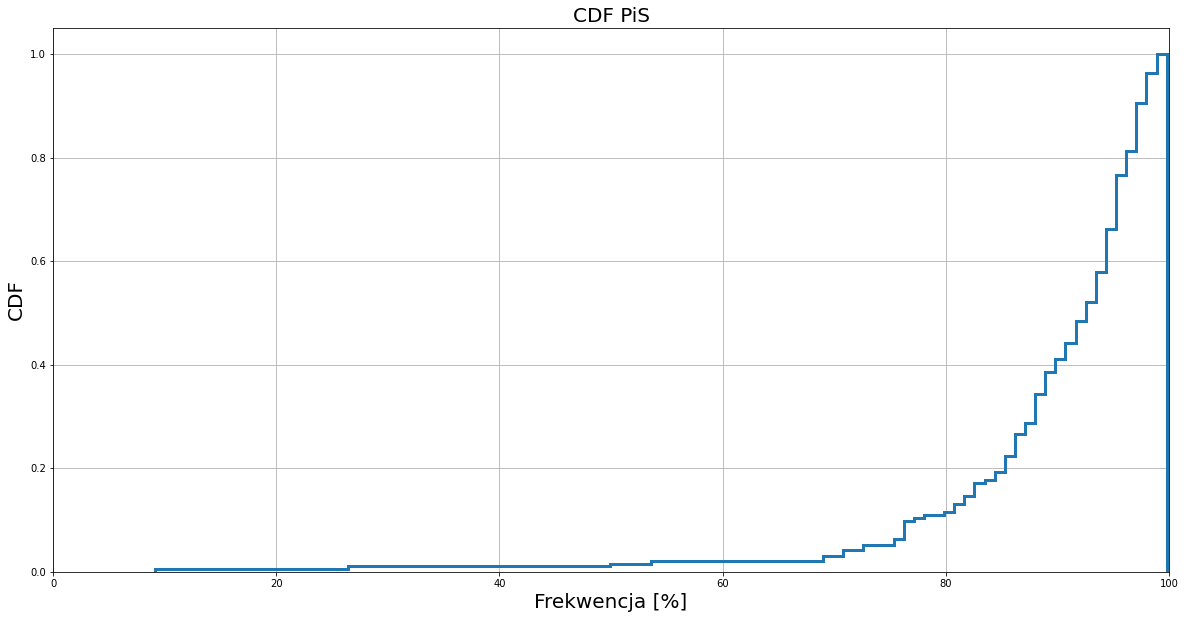

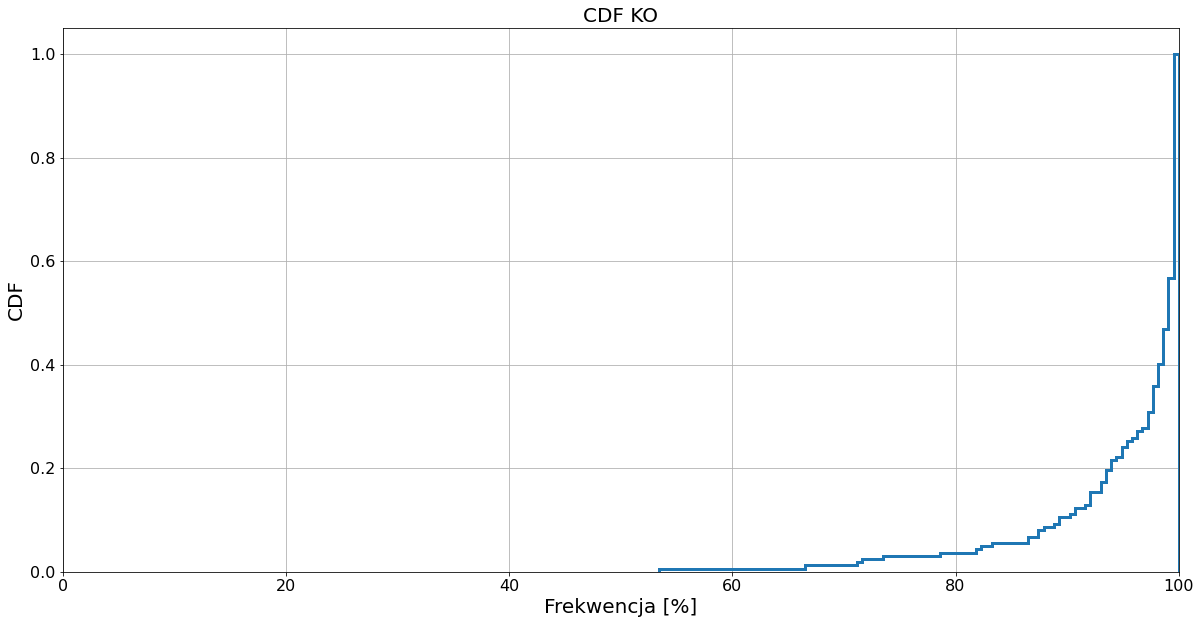

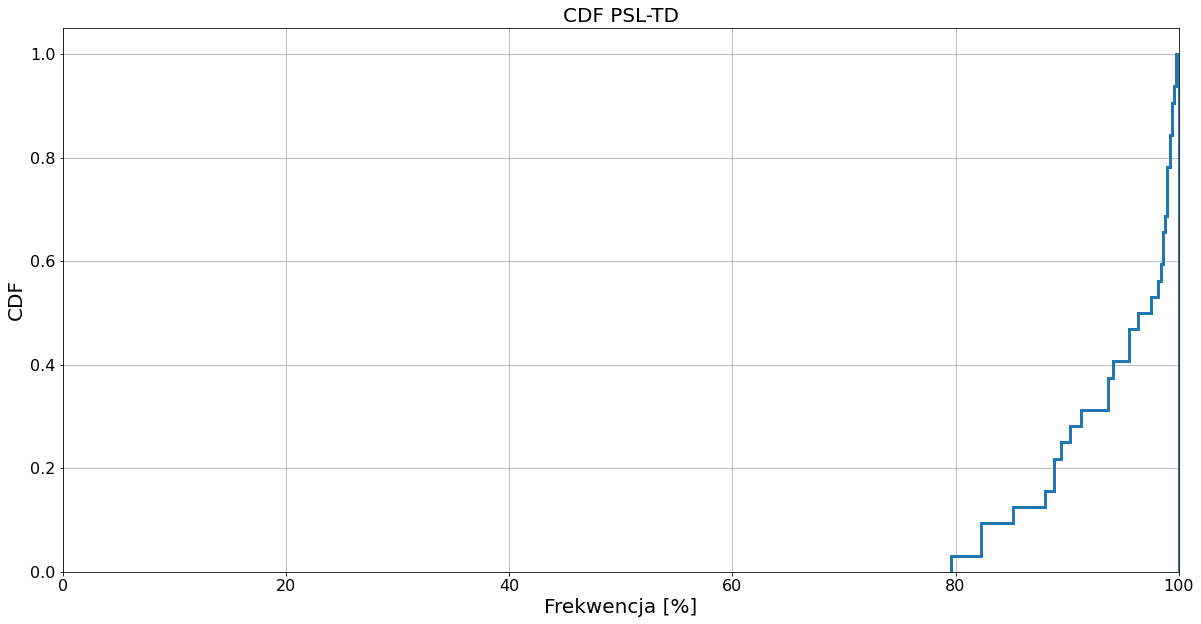

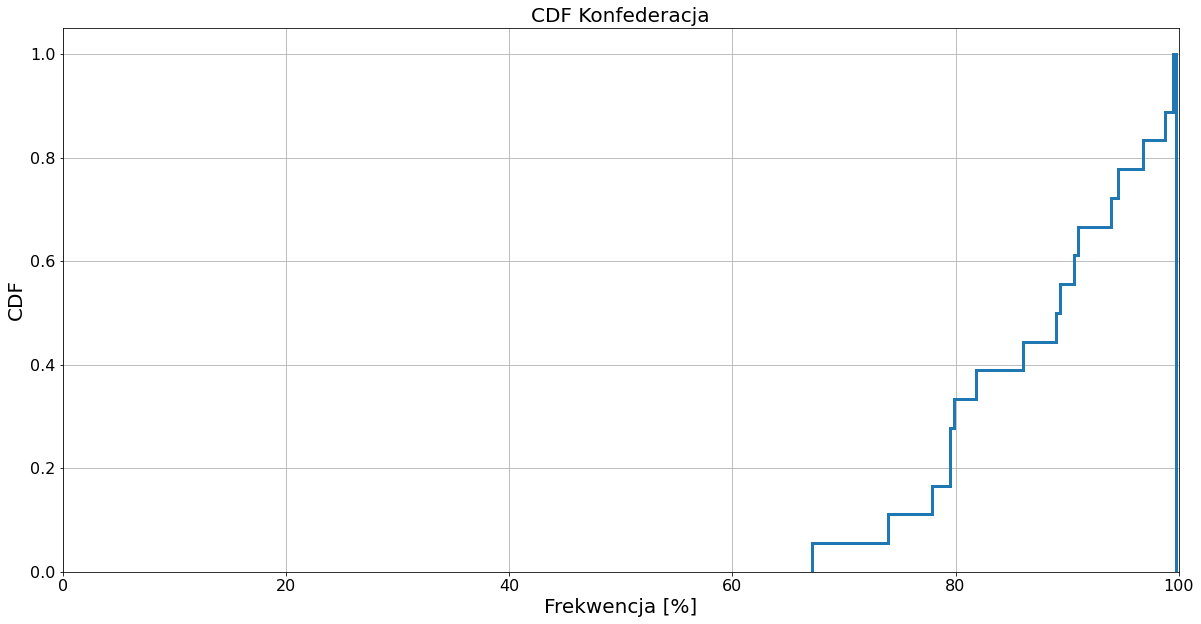

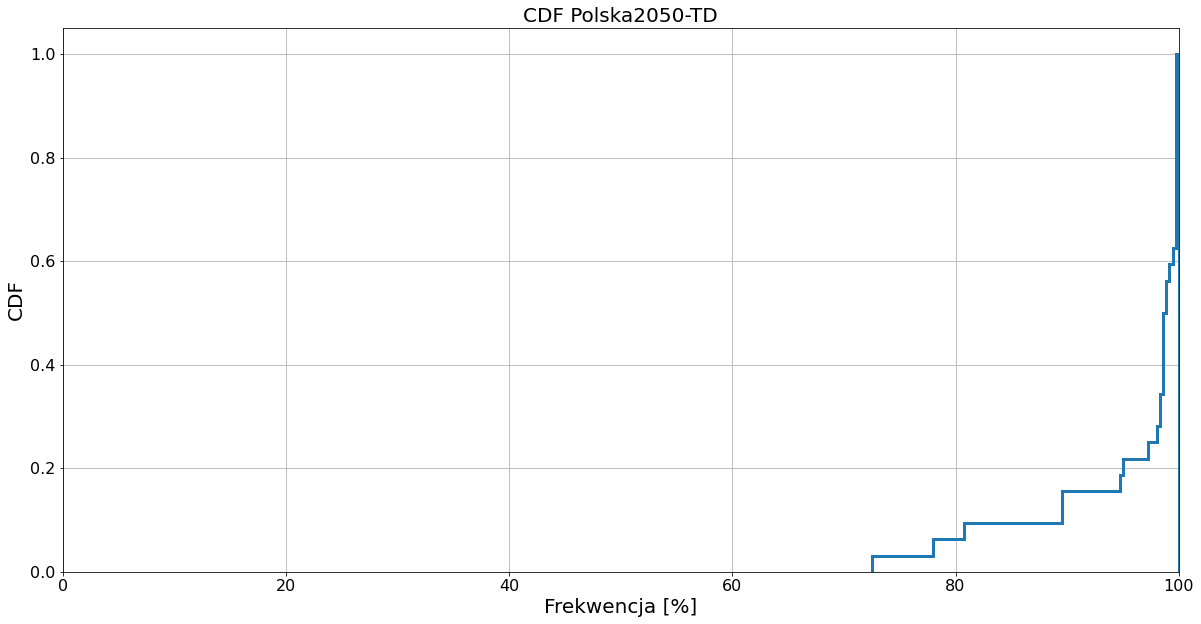

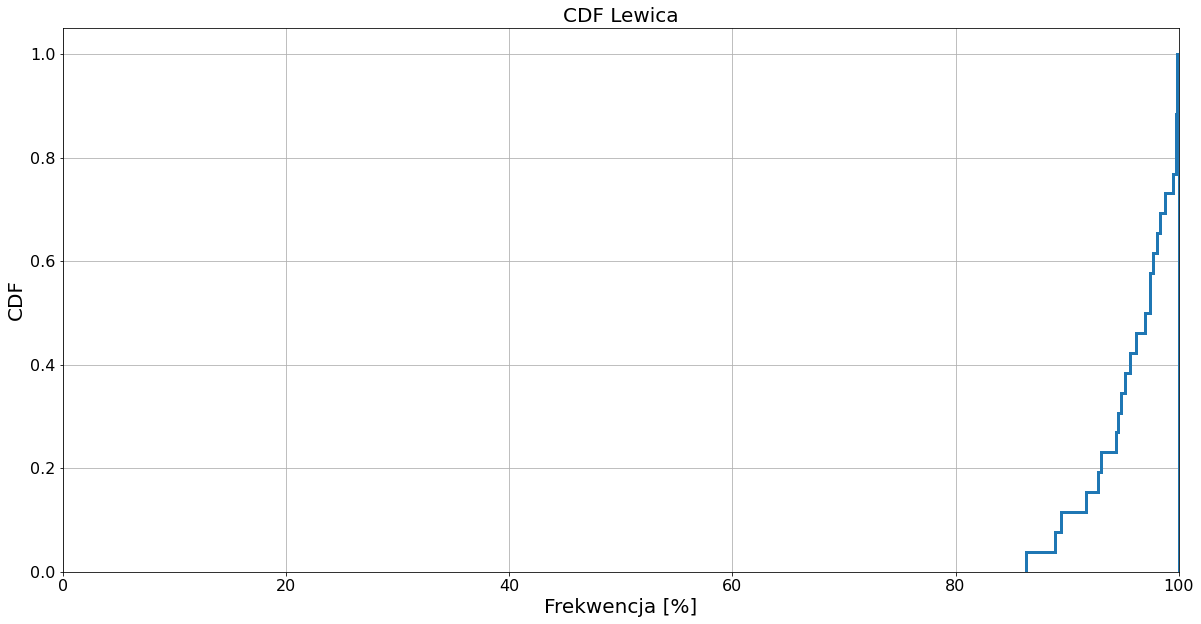

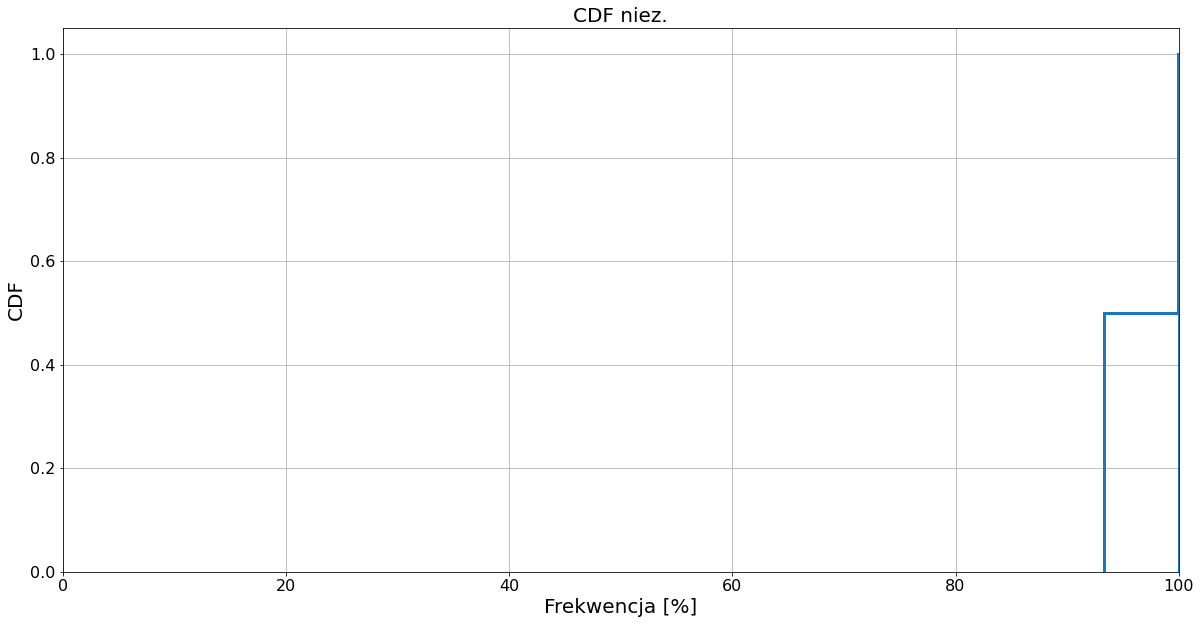

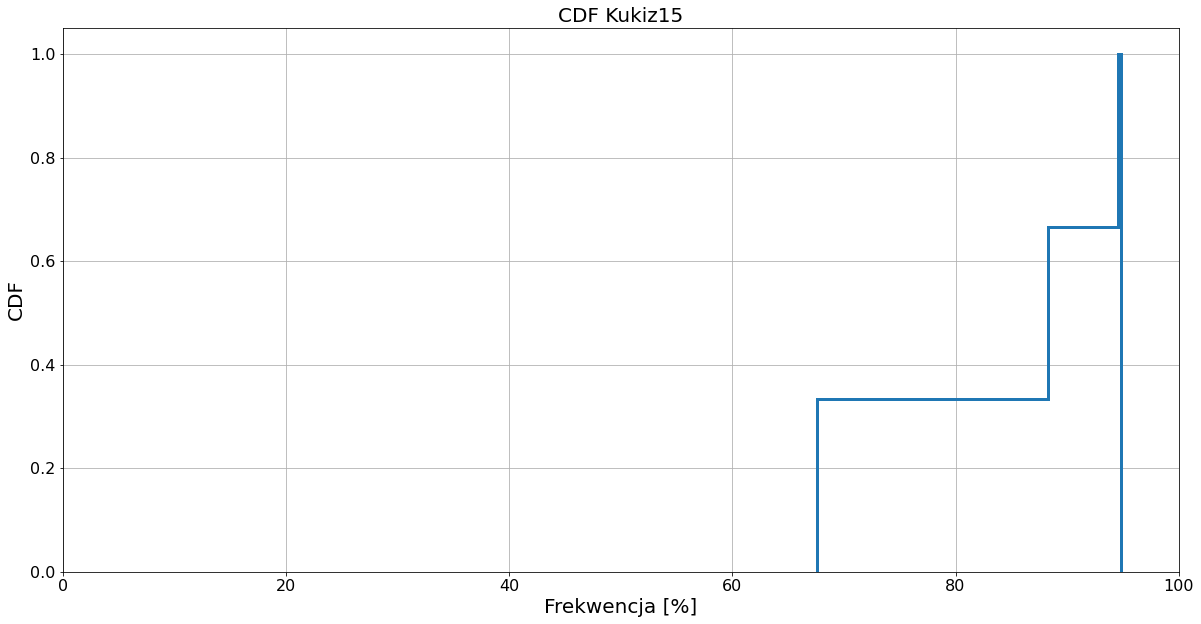

In [14]:
for club in mps_df.club.unique():
    plt.figure(figsize=(20,10))
    plt.hist(
        mps_df[mps_df.club == club].percentOfVoting,
        bins=100,
        cumulative=True,
        density=True,
        histtype='step',
        linewidth=3
    )
    plt.rcParams.update(
        {'font.size': 16}
    )
    plt.xlim(0,100)
    plt.grid(True)
    plt.title(f'CDF {club}', fontsize=20)
    plt.xlabel('Frekwencja [%]', fontsize=20)
    plt.ylabel('CDF', fontsize=20)
    plt.show()